# Customer Segmentation using K-Means

In this notebook we explore a dataset of mall customers and apply the K-Means clustering algorithm to identify patterns in customer behavior.

Customer segmentation is a common application of unsupervised learning. Instead of predicting a label, the algorithm tries to discover groups of similar data points.

The workflow followed in this notebook is:

1. Load and inspect the dataset
2. Visualize the most relevant features
3. Select the variables used for clustering
4. Normalize the data
5. Apply the K-Means algorithm
6. Visualize the resulting clusters

The goal is to understand how clustering works and how customer groups can be identified from behavioral data.

## Importing libraries

We start by importing the libraries required for this analysis.

These libraries are used for different purposes:

- **NumPy**: numerical operations and vectorized computations
- **Pandas**: data manipulation and dataset handling
- **Matplotlib / Seaborn**: data visualization

These tools allow us to explore the dataset and prepare it before applying the clustering algorithm.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the dataset

In this step we load the dataset containing customer information.

The dataset includes variables such as:
- customer ID
- gender
- age
- annual income
- spending score

For clustering purposes, we are particularly interested in the relationship between **income** and **spending behavior**, which may reveal natural customer segments.

In [69]:
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(url)

## Initial data exploration

Before applying any machine learning algorithm, it is important to understand the dataset.

Here we inspect the first rows of the dataset to verify:
- how the data is structured
- what variables are available
- whether the dataset was loaded correctly

This step helps us identify which features may be useful for clustering.

In [70]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


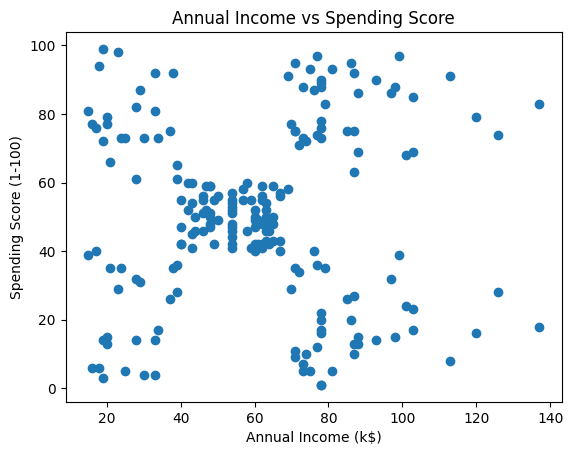

In [71]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.savefig("../static/Annual_IncomeXSpending_Score", dpi=150)
plt.show()

In [72]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X = X.values

print(X.shape)

(200, 2)


## Data normalization

K-Means relies on distance calculations to assign points to clusters.

Because of this, the scale of each feature can strongly influence the results.

To avoid one feature dominating the distance calculation, we normalize the dataset using **Min-Max scaling**, which transforms the values into a range between 0 and 1.

The transformation follows the formula:

$$
X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$


Where:

- $X$ is the original value  
- $X_{min}$ is the minimum value of the feature  
- $X_{max}$ is the maximum value of the feature  

This ensures both variables contribute equally to the clustering process.

In [73]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_norm = (X - X_min) / (X_max - X_min)

df_norm = pd.DataFrame(
    X_norm,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print(df_norm.head())

   Annual Income (k$)  Spending Score (1-100)
0            0.000000                0.387755
1            0.000000                0.816327
2            0.008197                0.051020
3            0.008197                0.775510
4            0.016393                0.397959


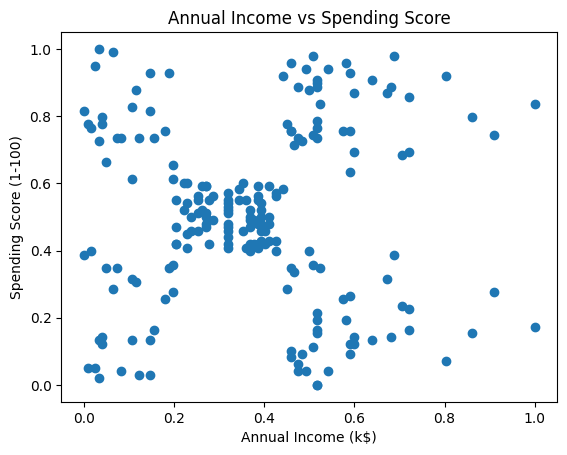

In [74]:
plt.scatter(df_norm["Annual Income (k$)"], df_norm["Spending Score (1-100)"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.savefig("../static/Annual_IncomeXSpending_Score Normalized", dpi=150)
plt.show()

## Applying the K-Means algorithm

Now that the data is prepared, we apply the K-Means clustering algorithm.

K-Means works through an iterative process:

1. Initialize cluster centroids
2. Assign each data point to the nearest centroid
3. Recompute the centroids as the mean of the assigned points
4. Repeat the process until convergence

The algorithm stops when the centroids stop changing significantly or when a maximum number of iterations is reached.

In [75]:
import sys
sys.path.append('../src')
from kmeans import Kmeans

In [76]:
#np.random.seed(13)

model = Kmeans(k=5)
model.fit(X)
print(model.clusters)

[3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4
 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1]


## Visualizing the clusters

Finally, we visualize the clusters identified by the algorithm.

Each point represents a customer and is colored according to the cluster it belongs to.

The centroids represent the center of each cluster and summarize the average characteristics of the customers in that group.

This visualization helps us understand how the algorithm segmented the customers based on income and spending behavior.

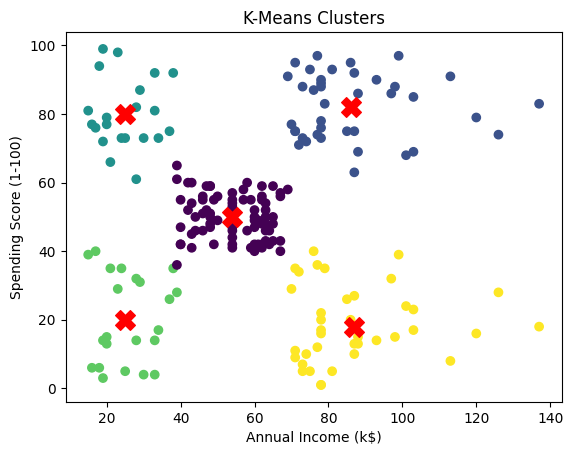

In [77]:
plt.scatter(X[:, 0], X[:, 1], c=model.clusters, cmap='viridis')
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], c='red', marker='X', s=200)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clusters")

plt.savefig("../static/K-means Clusters", dpi=150)
plt.show()

### Testing the normalized data

In [78]:
normalized_model = Kmeans(k=5)
normalized_model.fit(X_norm)

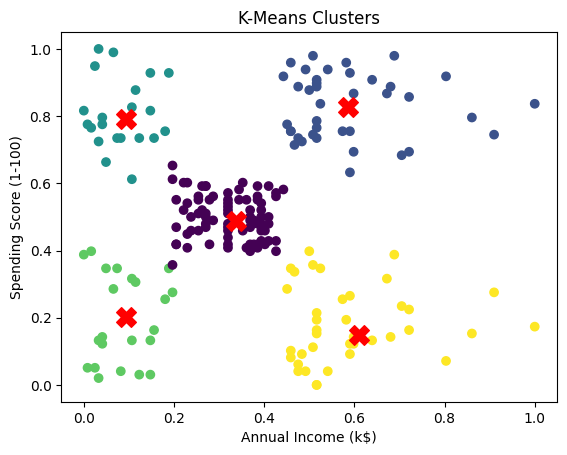

In [79]:
plt.scatter(X_norm[:, 0], X_norm[:, 1], c=model.clusters, cmap='viridis')
plt.scatter(normalized_model.centroids[:, 0], normalized_model.centroids[:, 1], c='red', marker='X', s=200)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clusters")

plt.savefig("../static/K-means Clusters Normalized", dpi=150)
plt.show()